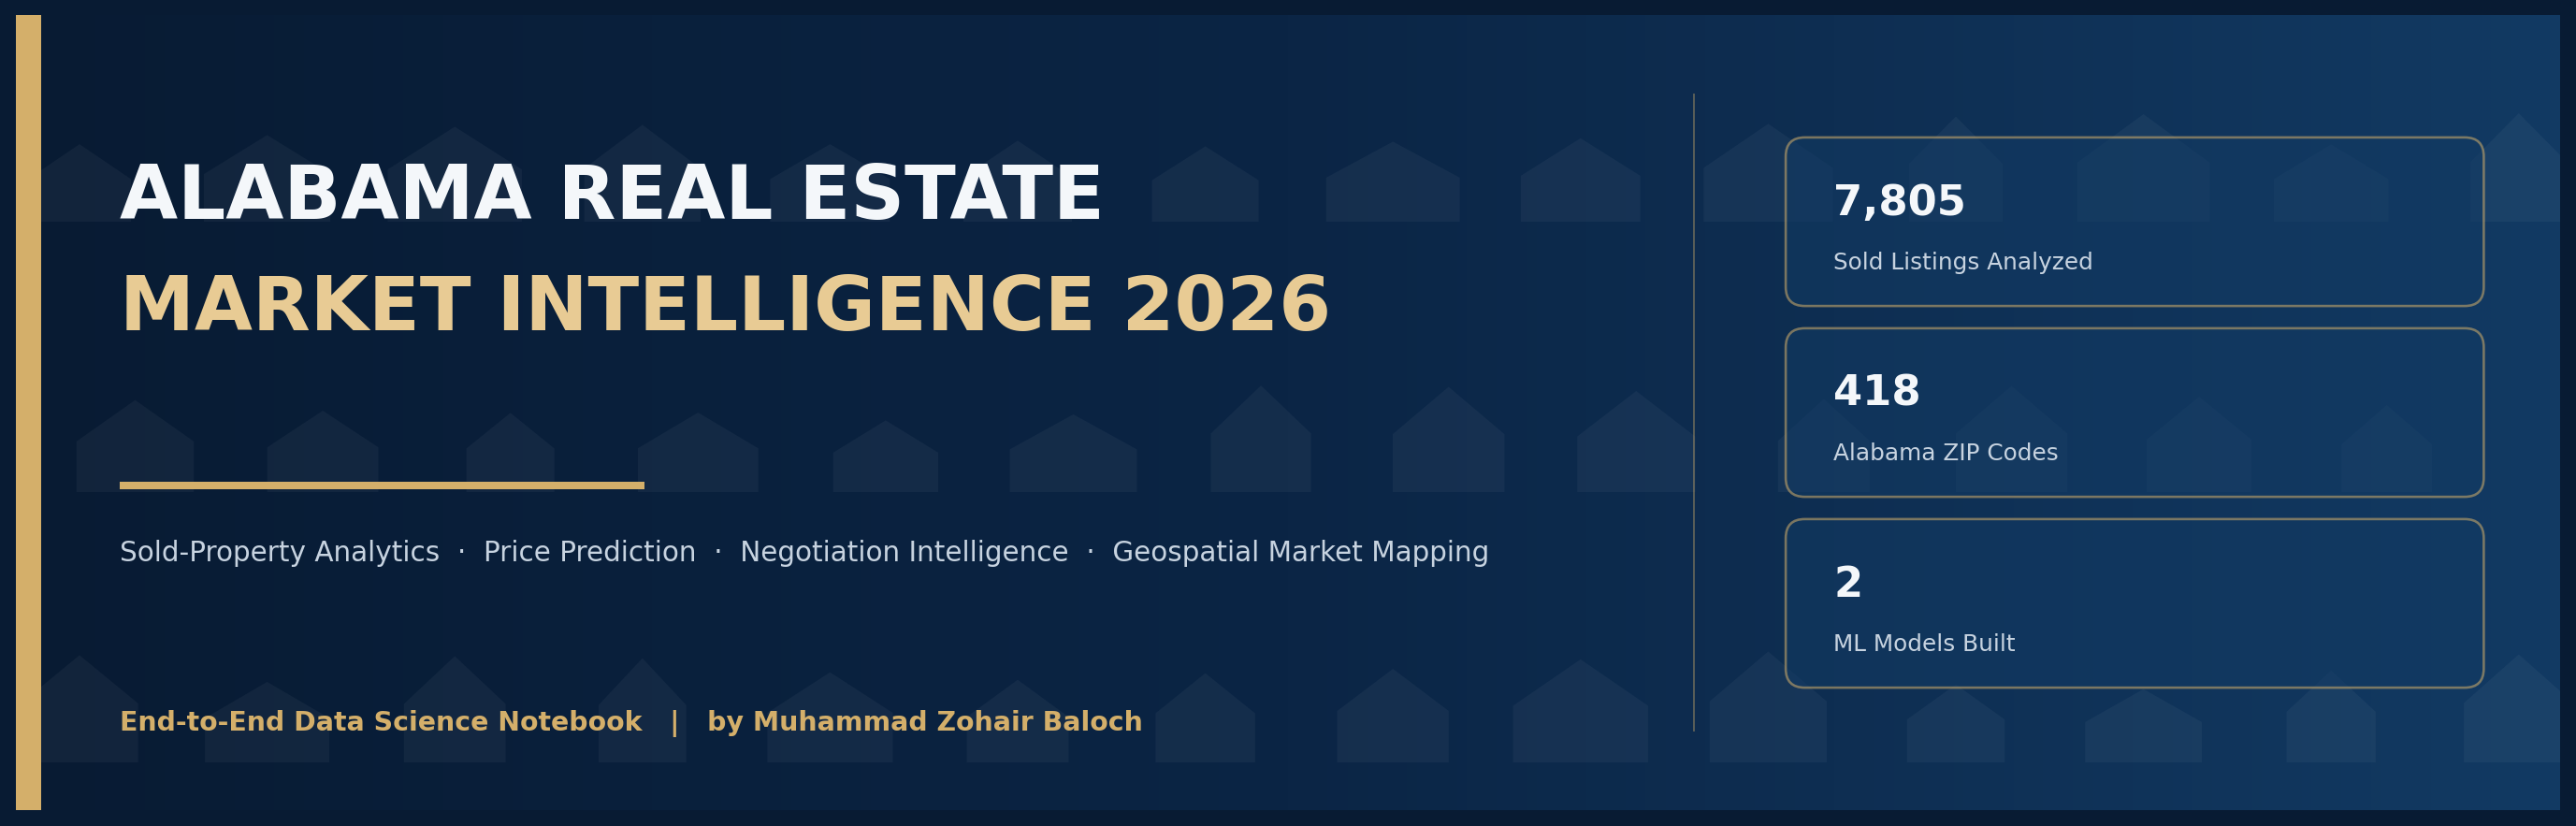


## Project Overview

Alabama's residential real estate market moved fast in 2026 — homes changed hands within weeks, and pricing power shifted noticeably between metros. This notebook analyzes **7,805 sold-property records** spanning single-family homes, condos, townhomes, and multi-family units across **418 ZIP codes** and dozens of Alabama cities, sourced from the Alabama Sold Real Estate Intelligence 2026 dataset.

**Business questions this notebook answers:**

1. What does the Alabama residential market actually look like right now — price levels, property mix, and geographic hot spots?
2. Which markets favor buyers, and which favor sellers? (asking-vs-sold price dynamics)
3. What drives a home's final sale price, and can we build a reliable price estimator?
4. Can we predict whether a home will sell **above**, **at**, or **below** asking price *before* it sells — a genuinely useful signal for agents and sellers pricing a new listing?

**What's inside:**

| Section | What it covers |
|---|---|
| 1. Data Quality & Cleaning | Auditing nulls, fixing corrupted records, engineering location features |
| 2. Market Overview (EDA) | Price distributions, property types, geographic breakdowns |
| 3. Geographic Market Map | Interactive statewide map of price and volume by city |
| 4. Negotiation Intelligence | Above/At/Below-asking dynamics by city, price band, property type |
| 5. Statistical Deep Dive | Correlations and drivers of price per square foot |
| 6. ML Model 1 — Price Prediction | Regression models benchmarked against a naive baseline, with cross-validation |
| 7. ML Model 2 — Negotiation Outcome Classifier | Predicting deal outcome before it happens, benchmarked against majority-class baseline |
| 8. Business Insights & Recommendations | Actionable takeaways for agents, sellers, and investors |

**Author:** Muhammad Zohair Baloch · BS Artificial Intelligence, KFUEIT ·

## 1. Setup & Data Loading

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, classification_report, confusion_matrix)
from xgboost import XGBRegressor, XGBClassifier
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

warnings.filterwarnings('ignore')

# Visual style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

NAVY = '#0B2545'
GOLD = '#C8A24A'
STEEL = '#2C6E91'
CORAL = '#D9534F'
PALETTE = [NAVY, GOLD, STEEL, CORAL, '#5C8001', '#8E44AD']

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries imported and configurations set successfully!")


Libraries imported and configurations set successfully!


In [2]:

df = pd.read_csv('alabama_sold_real_estate_intelligence_2026.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset shape: 7,805 rows x 27 columns


In [4]:
df.head()

,url,type,sub_type,listPrice,lastSoldPrice,soldOn,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,postal_code,is_valid_al_zip,sold_year,sold_month,sold_quarter,property_age,sold_to_list_ratio,price_premium_pct,negotiation_outcome,ratio_outlier_flag,price_per_sqft,text_clean,pii_redacted_flag
0,1106-Quail-Hollow-Rd-SW_Cullman_AL_35055_M9355...,single_family,NaN,"235,415.00","235,415.00",2055-05-24,"1,536.00",1.00,3.00,2.00,1.00,2.00,NaN,"2,022.00","35,055.00",True,NaN,NaN,NaN,4.00,1.00,0.00,At Asking,False,153.26,Under Construction-THIS GORGEOUS KERRY (E) WIL...,False
1,416-Saint-Clair-St_Birmingham_AL_35214_M83002-...,single_family,NaN,"128,100.00","135,000.00",2026-07-01,"1,496.00",1.00,3.00,2.00,2.00,2.00,1.00,"1,940.00","35,214.00",True,"2,026.00",7.00,3.00,86.00,1.05,5.39,Above Asking,False,90.24,Welcome HOME!!! [ADDRESS_REDACTED]reet is read...,True
2,4073-Crossings-Ln_Hoover_AL_35242_M79939-64500,single_family,NaN,"525,000.00","520,000.00",2026-07-01,"2,316.00",1.00,3.00,2.00,2.00,2.00,2.00,"2,005.00","35,242.00",True,"2,026.00",7.00,3.00,21.00,0.99,-0.95,Below Asking,False,224.53,Welcome to this charming one-level home in the...,False
3,1376-County-Road-235_Wedowee_AL_36278_M73656-6...,single_family,NaN,"549,900.00","549,900.00",2026-07-01,"2,000.00",1.00,4.00,3.00,3.00,3.00,NaN,"2,005.00","36,278.00",True,"2,026.00",7.00,3.00,21.00,1.00,0.00,At Asking,False,274.95,"THIS IS A COZY LAKE HOME WITH 2.7 ACRES, 119 F...",False
4,4727-Highway-18-W_Fayette_AL_35555_M79040-21449,single_family,NaN,"269,900.00","269,900.00",2026-07-01,"1,769.00",1.00,3.00,2.00,2.00,2.00,NaN,"1,968.00","35,555.00",True,"2,026.00",7.00,3.00,58.00,1.00,0.00,At Asking,False,152.57,"Tucked away on 4.72 acres in Fayette, this bea...",False


In [5]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   url                  7805 non-null   object 
 1   type                 7805 non-null   object 
 2   sub_type             565 non-null    object 
 3   listPrice            6999 non-null   float64
 4   lastSoldPrice        7805 non-null   float64
 5   soldOn               7805 non-null   object 
 6   sqft                 7805 non-null   float64
 7   stories              7398 non-null   float64
 8   beds                 7805 non-null   float64
 9   baths                7795 non-null   float64
 10  baths_full           7694 non-null   float64
 11  baths_full_calc      7698 non-null   float64
 12  garage               4204 non-null   float64
 13  year_built           7547 non-null   float64
 14  postal_code          7804 non-null   float64
 15  is_valid_al_zip      7805 non-null   b


### Initial data quality audit

The dataset ships with helpful pre-computed fields (`price_per_sqft`, `sold_to_list_ratio`, `negotiation_outcome`, `ratio_outlier_flag`), but a few raw fields need attention before analysis: missing values in `sub_type`, `listPrice`, and `garage`, and — as we'll see below — at least one corrupted date value.


In [6]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_report


,missing_count,missing_pct
sub_type,7240,92.76
garage,3601,46.14
text_clean,828,10.61
sold_to_list_ratio,806,10.33
listPrice,806,10.33
price_premium_pct,806,10.33
stories,407,5.21
property_age,258,3.31
year_built,258,3.31
baths_full,111,1.42


## 2. Data Cleaning & Feature Engineering


**Issues found and how we handle them:**

- `soldOn` contains at least one impossible future date (year 2055) — a data entry error. We flag and correct/exclude it.
- `sqft` has 2 records with a value of 0, which would distort price-per-sqft calculations.
- `sub_type` is only populated for condos/townhomes (by design) — we leave it as-is and rely on `type` as the primary category.
- City is not provided as its own column — we extract it from the listing `url`.
- `garage`, `stories`, `year_built`, `baths` have modest missingness — we impute conservatively (median/mode) only where needed for modeling, keeping raw EDA on non-null data.


In [7]:

# --- Fix corrupted date ---
df['soldOn_parsed'] = pd.to_datetime(df['soldOn'], errors='coerce')
bad_dates = df[df['soldOn_parsed'].dt.year > 2026]
print(f"Corrupted future-dated records found: {len(bad_dates)}")
bad_dates[['url', 'soldOn', 'lastSoldPrice']]


Corrupted future-dated records found: 1


,url,soldOn,lastSoldPrice
0,1106-Quail-Hollow-Rd-SW_Cullman_AL_35055_M9355...,2055-05-24,"235,415.00"


In [8]:

# Drop the single corrupted-date record (year 2055) from time-based analysis; keep it for price analysis
df_clean = df.copy()
df_clean.loc[df_clean['soldOn_parsed'].dt.year > 2026, 'soldOn_parsed'] = pd.NaT

# --- Extract city from the URL slug ---
df_clean['city'] = df_clean['url'].str.extract(r'_([A-Za-z\-]+)_AL_\d{5}')[0].str.replace('-', ' ')

# --- Remove zero-sqft records (data errors, can't compute price/sqft) ---
df_clean = df_clean[df_clean['sqft'] > 0].copy()

# --- Cap extreme price_per_sqft outliers (data errors, not real market signal) for EDA visuals only ---
ppsf_cap = df_clean['price_per_sqft'].quantile(0.995)
df_clean['price_per_sqft_capped'] = df_clean['price_per_sqft'].clip(upper=ppsf_cap)

print(f"Clean dataset: {df_clean.shape[0]:,} rows retained ({df.shape[0] - df_clean.shape[0]} dropped)")
print(f"Unique Alabama cities represented: {df_clean['city'].nunique()}")


Clean dataset: 7,803 rows retained (2 dropped)
Unique Alabama cities represented: 349


In [9]:

# --- Impute a small number of missing structural fields for modeling later ---
df_model_ready = df_clean.copy()
for col in ['garage', 'stories', 'baths', 'baths_full']:
    df_model_ready[col] = df_model_ready[col].fillna(df_model_ready[col].median())

df_model_ready['year_built'] = df_model_ready['year_built'].fillna(df_model_ready['year_built'].median())
df_model_ready['property_age'] = df_model_ready['property_age'].fillna(2026 - df_model_ready['year_built'])
df_model_ready['listPrice'] = df_model_ready['listPrice'].fillna(df_model_ready['lastSoldPrice'])

print("Post-imputation nulls in key modeling columns:")
print(df_model_ready[['garage','stories','baths','year_built','property_age','listPrice']].isnull().sum())


Post-imputation nulls in key modeling columns:
garage          0
stories         0
baths           0
year_built      0
property_age    0
listPrice       0
dtype: int64


## 3. Market Overview

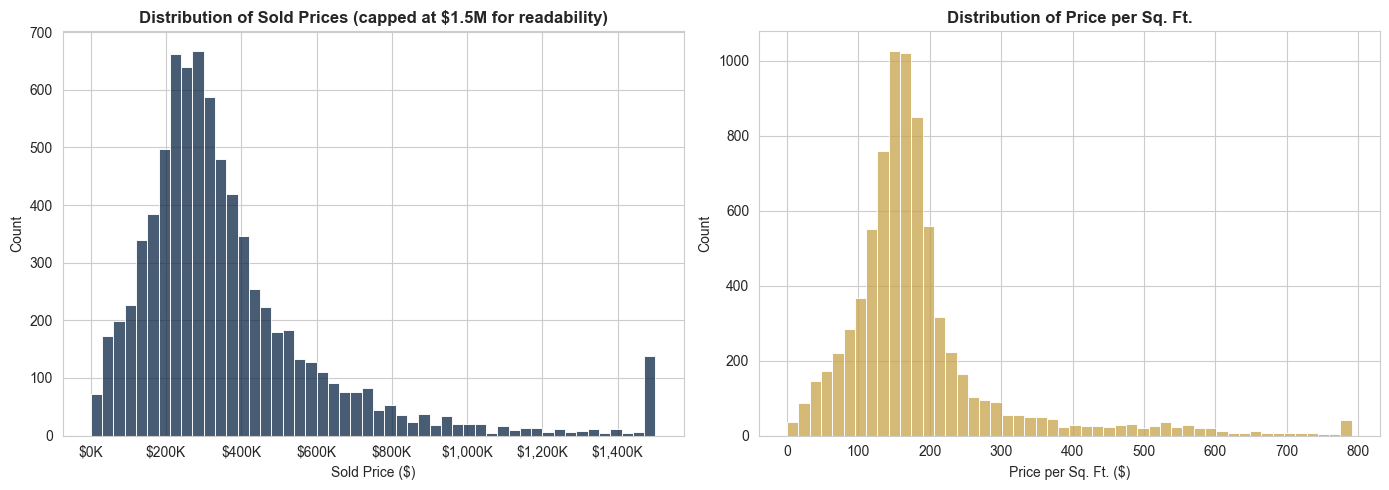

Median sold price: \$304,900
Median price per sq ft: \$162.20


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['lastSoldPrice'].clip(upper=1_500_000), bins=50, color=NAVY, ax=axes[0])
axes[0].set_title('Distribution of Sold Prices (capped at $1.5M for readability)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sold Price ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))

sns.histplot(df_clean['price_per_sqft_capped'], bins=50, color=GOLD, ax=axes[1])
axes[1].set_title('Distribution of Price per Sq. Ft.', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price per Sq. Ft. ($)')

plt.tight_layout()
plt.savefig('01_price_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median sold price: \${df_clean['lastSoldPrice'].median():,.0f}")
print(f"Median price per sq ft: \${df_clean['price_per_sqft'].median():.2f}")


In [11]:

type_summary = df_clean.groupby('type').agg(
    listings=('url', 'count'),
    median_price=('lastSoldPrice', 'median'),
    median_sqft=('sqft', 'median'),
    median_ppsf=('price_per_sqft', 'median')
).sort_values('listings', ascending=False)
type_summary


,listings,median_price,median_sqft,median_ppsf
type,,,,
single_family,7079,"300,000.00","1,884.00",159.09
condos,502,"385,000.00","1,235.50",351.63
townhomes,195,"275,000.00","1,557.00",166.67
multi_family,17,"195,000.00","2,125.00",98.98
other,9,"321,200.00","1,568.00",221.98
duplex_triplex,1,"189,900.00","1,188.00",159.85


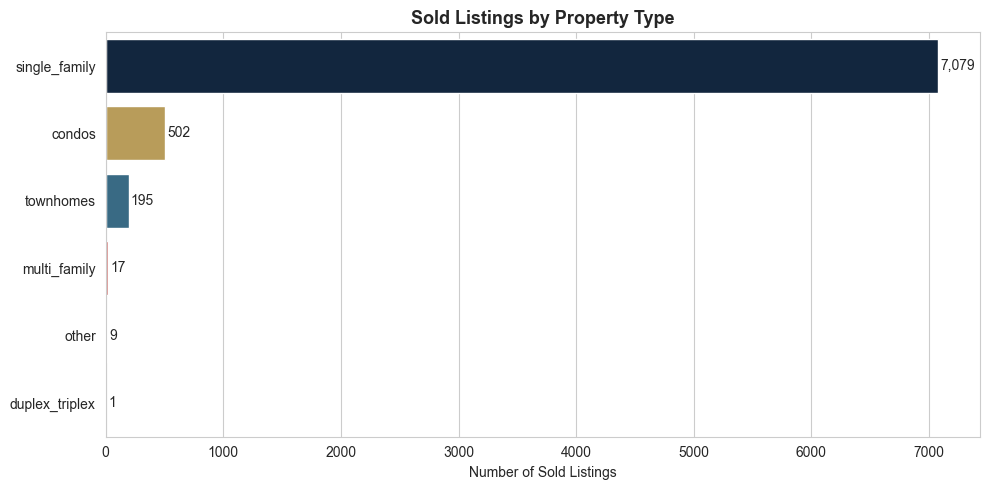

In [12]:

fig, ax = plt.subplots(figsize=(10, 5))
order = df_clean['type'].value_counts().index
sns.barplot(x=df_clean['type'].value_counts().values, y=order, palette=PALETTE, ax=ax)
ax.set_title('Sold Listings by Property Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Sold Listings')
ax.set_ylabel('')
for i, v in enumerate(df_clean['type'].value_counts().values):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('02_listings_by_type.png', dpi=150, bbox_inches='tight')
plt.show()


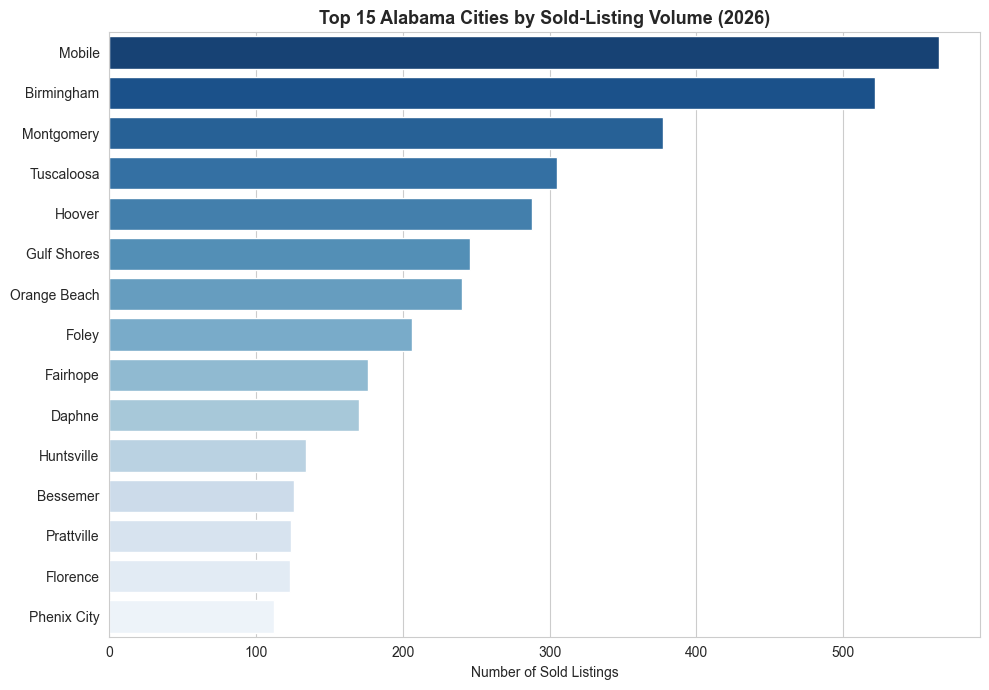

In [13]:

top_cities = df_clean['city'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_cities.values, y=top_cities.index, palette=sns.color_palette('Blues_r', 15), ax=ax)
ax.set_title('Top 15 Alabama Cities by Sold-Listing Volume (2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Sold Listings')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('03_top_cities_volume.png', dpi=150, bbox_inches='tight')
plt.show()


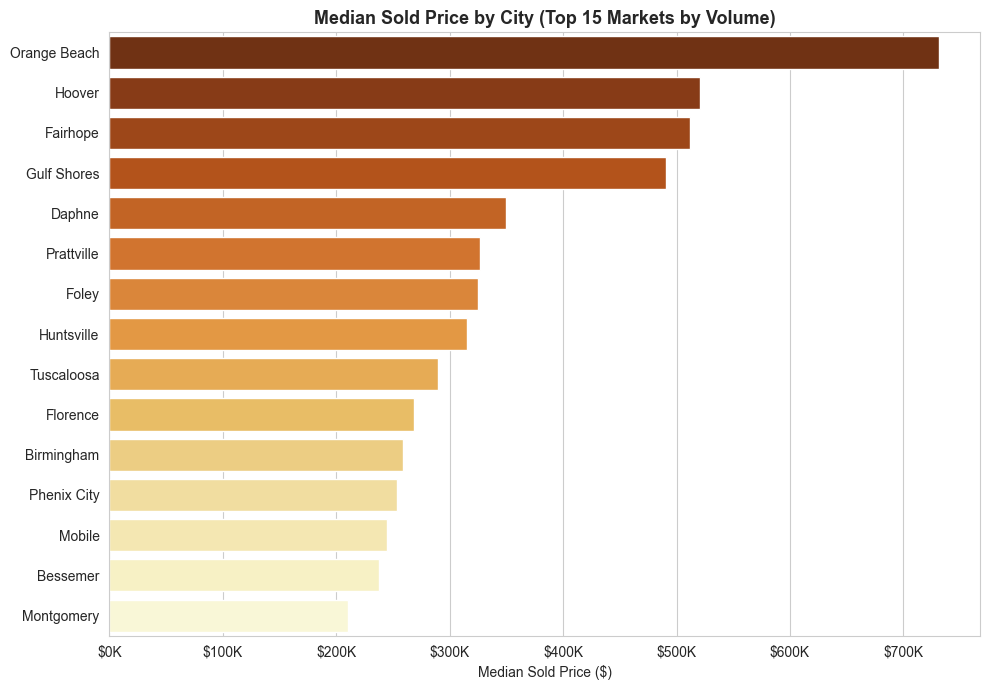

Most expensive market (top-15 by volume): Orange Beach — median \$731,000
Most affordable market (top-15 by volume): Montgomery — median \$210,000


In [14]:

city_price = df_clean[df_clean['city'].isin(top_cities.index)].groupby('city')['lastSoldPrice'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=city_price.values, y=city_price.index, palette=sns.color_palette('YlOrBr_r', 15), ax=ax)
ax.set_title('Median Sold Price by City (Top 15 Markets by Volume)', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Sold Price ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('04_median_price_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most expensive market (top-15 by volume): {city_price.index[0]} — median \${city_price.iloc[0]:,.0f}")
print(f"Most affordable market (top-15 by volume): {city_price.index[-1]} — median \${city_price.iloc[-1]:,.0f}")



**Reading the market:** Sold-listing volume is heavily concentrated in a handful of metros — Mobile, Birmingham, Montgomery, and Tuscaloosa alone account for a large share of transactions. But volume leaders and price leaders are *not* the same cities: high-transaction markets tend to be more affordable, while lower-volume suburban markets (e.g. around Birmingham and Baldwin County) command materially higher median prices — a classic sign of distinct starter-home vs. move-up/luxury submarkets within the same state.


## 3. Geographic Market Map


Price and volume tables only tell part of the location story — an interactive map makes the statewide pattern immediate. Below, each Alabama city with sufficient sold-listing volume is plotted by its approximate coordinates: **bubble size** reflects transaction volume, and **color** reflects median sold price.

*(City-level centroid coordinates are used for visualization purposes — points represent the general city location, not individual properties.)*


In [15]:

# Curated centroid coordinates for Alabama cities with meaningful sold-listing volume
city_coords = {
    'Mobile': (30.6954, -88.0399), 'Birmingham': (33.5207, -86.8025), 'Montgomery': (32.3792, -86.3077),
    'Tuscaloosa': (33.2098, -87.5692), 'Hoover': (33.4054, -86.8114), 'Gulf Shores': (30.2461, -87.7008),
    'Orange Beach': (30.2946, -87.5772), 'Foley': (30.4069, -87.6836), 'Fairhope': (30.5229, -87.9033),
    'Daphne': (30.6035, -87.9036), 'Huntsville': (34.7304, -86.5861), 'Bessemer': (33.4018, -86.9544),
    'Prattville': (32.4640, -86.4597), 'Florence': (34.7998, -87.6773), 'Phenix City': (32.4709, -85.0008),
    'Northport': (33.2290, -87.5772), 'Trussville': (33.6198, -86.6136), 'Pike Road': (32.2846, -86.0805),
    'Cullman': (34.1748, -86.8436), 'Wetumpka': (32.5335, -86.2122), 'Calera': (33.1057, -86.7508),
    'Mountain Brk': (33.5001, -86.7433), 'Vestavia': (33.4488, -86.7877), 'Vestavia Hills': (33.4488, -86.7877),
    'Anniston': (33.6598, -85.8316), 'Spanish Fort': (30.6699, -87.9153), 'Chelsea': (33.3401, -86.6330),
    'Pelham': (33.2857, -86.8100), 'Theodore': (30.5502, -88.1717), 'Helena': (33.2965, -86.8630),
    'Alabaster': (33.2246, -86.8114), 'Madison': (34.6993, -86.7483), 'Semmes': (30.7702, -88.2517),
    'Saraland': (30.8207, -88.0725), 'Athens': (34.8040, -86.9722), 'Fultondale': (33.6248, -86.8017),
    'Deatsville': (32.6521, -86.3844), 'Robertsdale': (30.5546, -87.7092), 'Homewood': (33.4707, -86.8100),
    'Irondale': (33.5546, -86.7128),
}

city_geo = (
    df_clean[df_clean['city'].isin(city_coords.keys())]
    .groupby('city')
    .agg(listings=('url', 'count'), median_price=('lastSoldPrice', 'median'), median_ppsf=('price_per_sqft', 'median'))
    .reset_index()
)
city_geo['lat'] = city_geo['city'].map(lambda c: city_coords[c][0])
city_geo['lon'] = city_geo['city'].map(lambda c: city_coords[c][1])
city_geo = city_geo[city_geo['listings'] >= 10]

fig_map = px.scatter_mapbox(
    city_geo, lat='lat', lon='lon', size='listings', color='median_price',
    hover_name='city',
    hover_data={'listings': True, 'median_price': ':$,.0f', 'median_ppsf': ':$.2f', 'lat': False, 'lon': False},
    color_continuous_scale='YlOrRd', size_max=42, zoom=5.6,
    center={'lat': 32.8, 'lon': -86.8},
    mapbox_style='open-street-map',
    title='Alabama Sold-Property Market: Volume (bubble size) & Median Price (color) by City'
)
fig_map.update_layout(height=560, margin={'r':0, 't':40, 'l':0, 'b':0},
                       coloraxis_colorbar=dict(title='Median<br>Sold Price'))
fig_map.show()



*Note: the interactive map above requires a JS-enabled notebook viewer (Jupyter, JupyterLab, Kaggle, Colab). For static viewers such as GitHub's file preview, a non-interactive version is rendered below with the same encoding.*


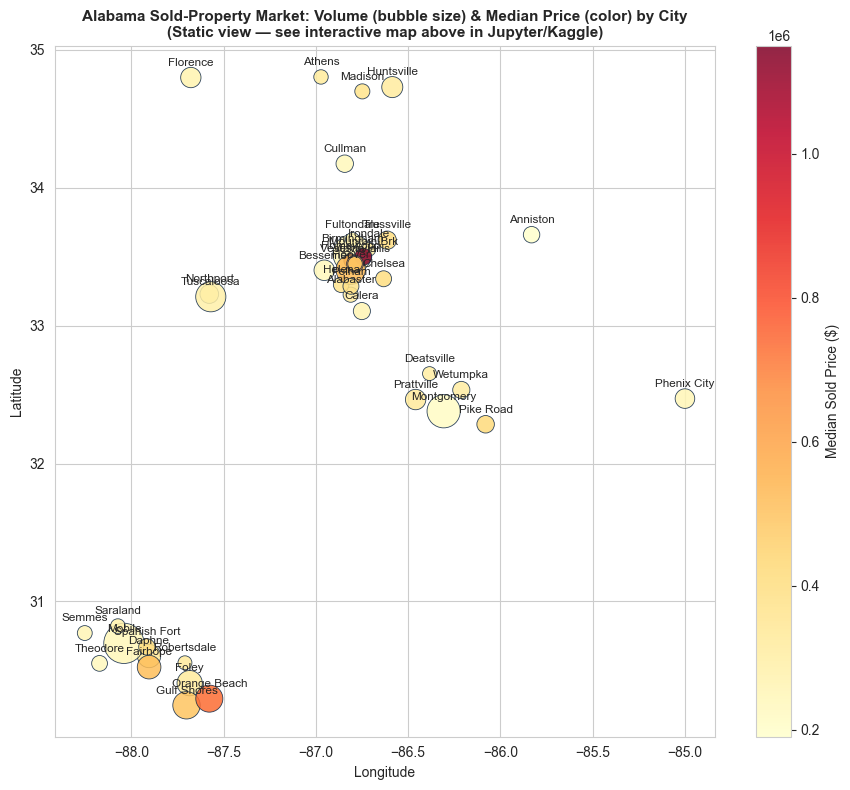

In [16]:

fig, ax = plt.subplots(figsize=(9, 8))
sizes = (city_geo['listings'] / city_geo['listings'].max()) * 800 + 40
sc = ax.scatter(city_geo['lon'], city_geo['lat'], s=sizes, c=city_geo['median_price'],
                 cmap='YlOrRd', edgecolors=NAVY, linewidths=0.6, alpha=0.85)

for _, row in city_geo[city_geo['listings'] >= 40].iterrows():
    ax.annotate(row['city'], (row['lon'], row['lat']), fontsize=8.5, ha='center', va='bottom',
                xytext=(0, 7), textcoords='offset points')

cbar = plt.colorbar(sc, ax=ax, label='Median Sold Price ($)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Alabama Sold-Property Market: Volume (bubble size) & Median Price (color) by City\n(Static view — see interactive map above in Jupyter/Kaggle)',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('14_static_geo_map.png', dpi=150, bbox_inches='tight')
plt.show()



**Reading the map:** The coastal Baldwin County cluster (Gulf Shores, Orange Beach, Fairhope, Daphne) stands out as a distinct high-price pocket relative to its transaction volume — consistent with vacation/second-home demand inflating prices beyond what local population alone would suggest. The Birmingham-metro suburbs (Hoover, Vestavia Hills, Mountain Brook, Trussville) form a second premium cluster, while the state's core urban markets (Mobile, Montgomery, Tuscaloosa) show high volume at more moderate price points.


## 4. Negotiation Intelligence: Who Has Pricing Power?


The `negotiation_outcome` field (derived from `sold_to_list_ratio`) tells us, for every closed sale, whether the buyer paid **above**, **at**, or **below** the seller's asking price. This is one of the most actionable signals in the dataset — it's a direct read on local market temperature.


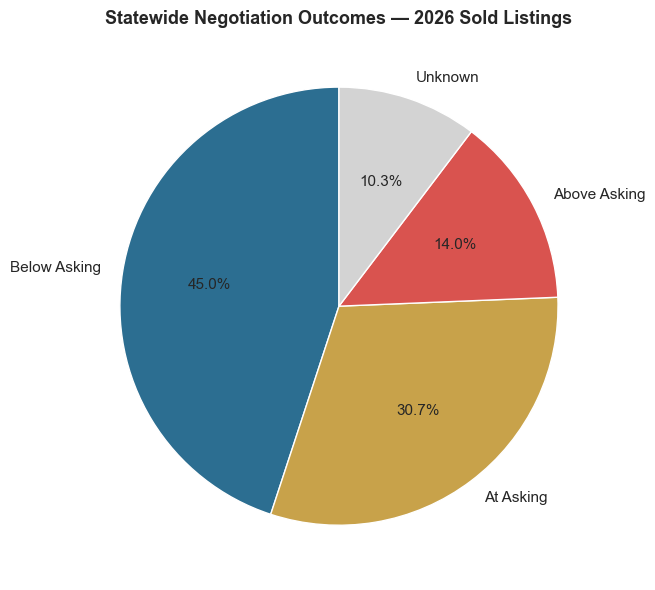

negotiation_outcome
Below Asking   45.00
At Asking      30.70
Above Asking   14.00
Unknown        10.30
Name: count, dtype: float64

In [17]:

outcome_counts = df_clean['negotiation_outcome'].value_counts()
outcome_pct = (outcome_counts / outcome_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 6))
colors_map = {'Below Asking': STEEL, 'At Asking': GOLD, 'Above Asking': CORAL, 'Unknown': 'lightgray'}
wedges, texts, autotexts = ax.pie(
    outcome_counts.values, labels=outcome_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=[colors_map.get(x, 'gray') for x in outcome_counts.index],
    textprops={'fontsize': 11}
)
ax.set_title('Statewide Negotiation Outcomes — 2026 Sold Listings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_negotiation_outcomes_pie.png', dpi=150, bbox_inches='tight')
plt.show()

outcome_pct


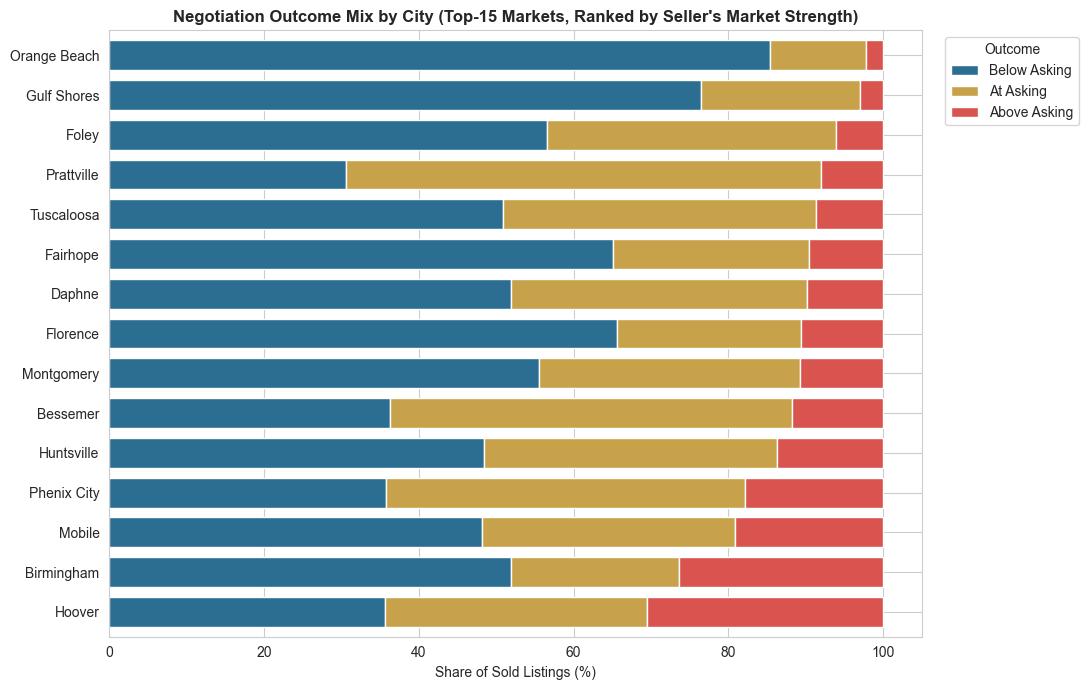

In [18]:

neg_by_city = (
    df_clean[df_clean['city'].isin(top_cities.index) & (df_clean['negotiation_outcome'] != 'Unknown')]
    .groupby(['city', 'negotiation_outcome']).size()
    .unstack(fill_value=0)
)
neg_by_city_pct = neg_by_city.div(neg_by_city.sum(axis=1), axis=0) * 100
neg_by_city_pct = neg_by_city_pct[['Below Asking', 'At Asking', 'Above Asking']]
neg_by_city_pct = neg_by_city_pct.loc[neg_by_city_pct['Above Asking'].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 7))
neg_by_city_pct.plot(kind='barh', stacked=True, color=[STEEL, GOLD, CORAL], ax=ax, width=0.75)
ax.set_title('Negotiation Outcome Mix by City (Top-15 Markets, Ranked by Seller\'s Market Strength)', fontsize=12, fontweight='bold')
ax.set_xlabel('Share of Sold Listings (%)')
ax.set_ylabel('')
ax.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('06_negotiation_by_city.png', dpi=150, bbox_inches='tight')
plt.show()


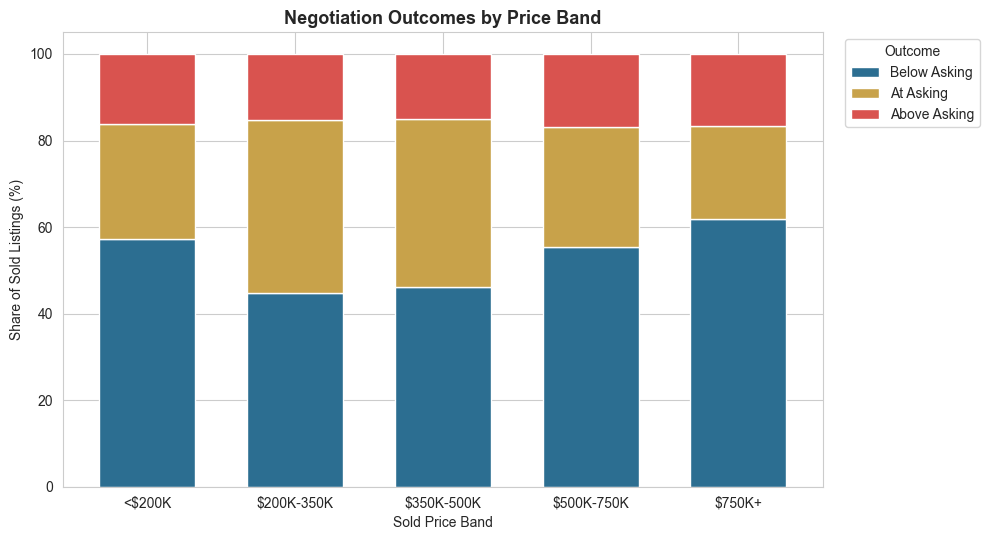

In [19]:

price_bins = [0, 200000, 350000, 500000, 750000, np.inf]
price_labels = ['<$200K', '$200K-350K', '$350K-500K', '$500K-750K', '$750K+']
df_clean['price_band'] = pd.cut(df_clean['lastSoldPrice'], bins=price_bins, labels=price_labels)

neg_by_band = (
    df_clean[df_clean['negotiation_outcome'] != 'Unknown']
    .groupby(['price_band', 'negotiation_outcome']).size()
    .unstack(fill_value=0)
)
neg_by_band_pct = neg_by_band.div(neg_by_band.sum(axis=1), axis=0) * 100
neg_by_band_pct = neg_by_band_pct[['Below Asking', 'At Asking', 'Above Asking']]

fig, ax = plt.subplots(figsize=(10, 5.5))
neg_by_band_pct.plot(kind='bar', stacked=True, color=[STEEL, GOLD, CORAL], ax=ax, width=0.65)
ax.set_title('Negotiation Outcomes by Price Band', fontsize=13, fontweight='bold')
ax.set_ylabel('Share of Sold Listings (%)')
ax.set_xlabel('Sold Price Band')
plt.xticks(rotation=0)
ax.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('07_negotiation_by_price_band.png', dpi=150, bbox_inches='tight')
plt.show()



**Key read:** Entry-level homes (under \$200K) sell above asking far more often than luxury properties, which is consistent with tight starter-home inventory driving bidding competition — while higher price bands see proportionally more price concessions, reflecting thinner buyer pools at the top of the market.


## 5. Statistical Deep Dive: What Drives Price per Sq. Ft.?

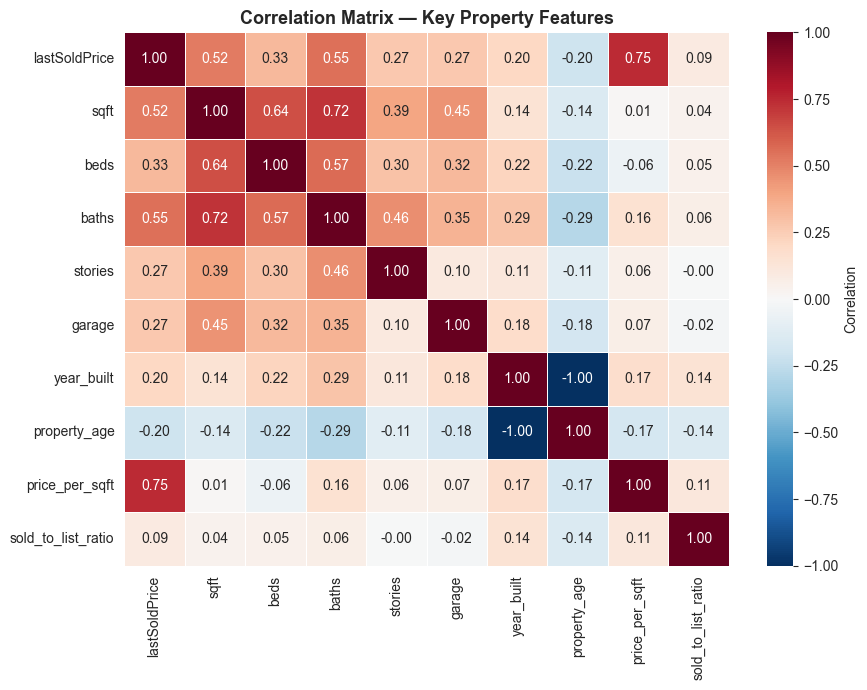

In [20]:

numeric_cols = ['lastSoldPrice', 'sqft', 'beds', 'baths', 'stories', 'garage',
                 'year_built', 'property_age', 'price_per_sqft', 'sold_to_list_ratio']
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix — Key Property Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


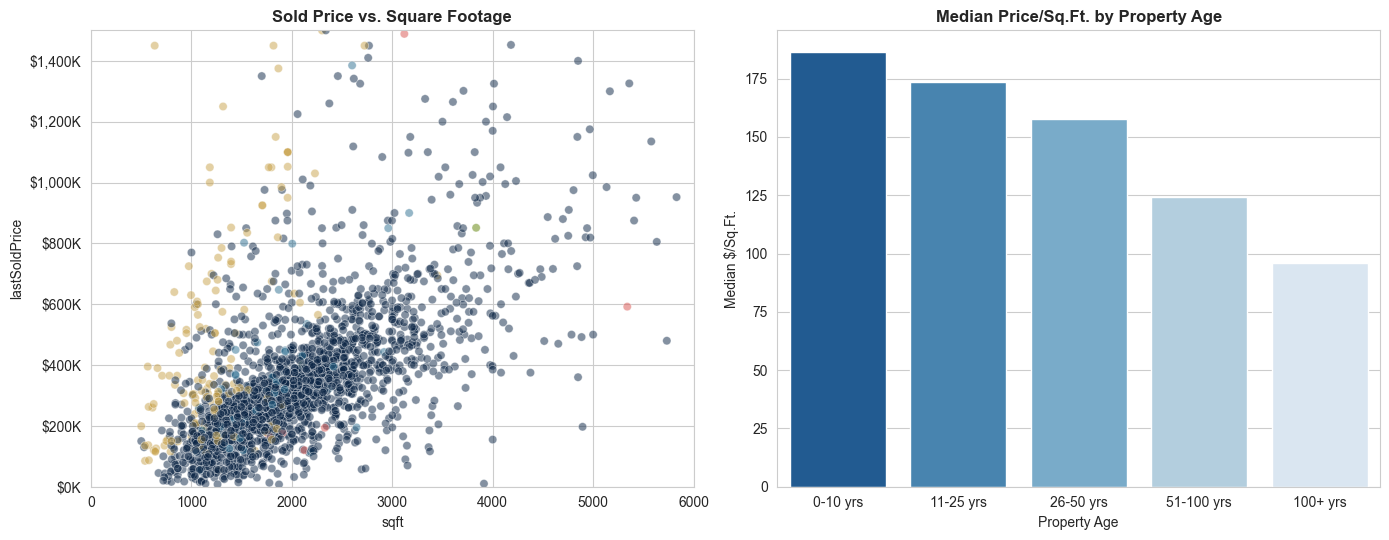

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=df_clean.sample(min(2500, len(df_clean)), random_state=42),
                 x='sqft', y='lastSoldPrice', hue='type', palette=PALETTE, alpha=0.5, ax=axes[0], legend=False)
axes[0].set_title('Sold Price vs. Square Footage', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1_500_000)
axes[0].set_xlim(0, 6000)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))

age_bins = [0, 10, 25, 50, 100, 200]
age_labels = ['0-10 yrs', '11-25 yrs', '26-50 yrs', '51-100 yrs', '100+ yrs']
df_clean['age_band'] = pd.cut(df_clean['property_age'], bins=age_bins, labels=age_labels)
age_ppsf = df_clean.groupby('age_band')['price_per_sqft'].median()
sns.barplot(x=age_ppsf.index, y=age_ppsf.values, palette=sns.color_palette('Blues_r', 5), ax=axes[1])
axes[1].set_title('Median Price/Sq.Ft. by Property Age', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Property Age')
axes[1].set_ylabel('Median $/Sq.Ft.')

plt.tight_layout()
plt.savefig('09_price_drivers.png', dpi=150, bbox_inches='tight')
plt.show()



**Takeaway:** Square footage is, unsurprisingly, the single strongest correlate of sold price — but the relationship is sub-linear on a per-square-foot basis: newer builds (0-10 years) command a clear price-per-square-foot premium over older housing stock, reflecting buyer willingness to pay up for modern finishes, efficiency, and lower deferred-maintenance risk.


## 6. ML Model 1 — Home Sale Price Prediction


**Goal:** Build a regression model that estimates a home's final sold price from its physical and location characteristics — a simplified Automated Valuation Model (AVM), the kind of tool used by agents, appraisers, and platforms like Zillow's Zestimate.

**Features used:** square footage, beds, baths, garage, stories, property age, property type, and city (encoded). We deliberately **exclude `listPrice`** from this model — the goal is to value a home independent of what a seller *asked* for it, which is the harder and more useful prediction task.

**Models compared:** Linear Regression (baseline), Random Forest, and XGBoost.


In [22]:

model_df = df_model_ready.copy()

# Keep only categories with reasonable sample size for city encoding
city_counts = model_df['city'].value_counts()
model_df['city_grouped'] = model_df['city'].where(model_df['city'].isin(city_counts[city_counts >= 20].index), 'Other')

features = ['sqft', 'beds', 'baths', 'garage', 'stories', 'property_age', 'type', 'city_grouped']
target = 'lastSoldPrice'

model_df = model_df.dropna(subset=features + [target])
model_df = model_df[(model_df['lastSoldPrice'] > 10000) & (model_df['lastSoldPrice'] < 3_000_000)]  # trim extreme outliers

X = model_df[features].copy()
y = model_df[target].copy()

le_type = LabelEncoder()
le_city = LabelEncoder()
X['type'] = le_type.fit_transform(X['type'])
X['city_grouped'] = le_city.fit_transform(X['city_grouped'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")


Training rows: 6,212  |  Test rows: 1,553



**Setting a baseline first.** Before trusting any model, we need to know what "good" looks like. A naive but reasonable baseline for home valuation is simply: *predict the median sold price for that city*. If our ML models can't beat this, they're not earning their complexity.


In [23]:

# --- Naive baseline: predict each test-set home's price as its city's median training-set price ---
train_city_median = X_train.join(y_train).copy()
train_city_median['city_grouped'] = model_df.loc[X_train.index, 'city_grouped'].values
city_median_map = train_city_median.groupby('city_grouped')[target].median()
overall_median = y_train.median()

test_cities = model_df.loc[X_test.index, 'city_grouped'].values
baseline_preds = pd.Series(test_cities).map(city_median_map).fillna(overall_median).values

results = {'Baseline (City Median)': baseline_preds}


In [24]:

lr = LinearRegression()
lr.fit(X_train, y_train)
results['Linear Regression'] = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results['Random Forest'] = rf.predict(X_test)

xgb = XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
                    colsample_bytree=0.8, random_state=42)
xgb.fit(X_train, y_train)
results['XGBoost'] = xgb.predict(X_test)

metrics = []
for name, preds in results.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    metrics.append({'Model': name, 'MAE ($)': round(mae), 'RMSE ($)': round(rmse), 'R2': round(r2, 3)})

metrics_df = pd.DataFrame(metrics).sort_values('R2', ascending=False)
metrics_df


,Model,MAE ($),RMSE ($),R2
3,XGBoost,90165,157587,0.71
2,Random Forest,101456,181045,0.62
1,Linear Regression,126266,211472,0.48
0,Baseline (City Median),149652,257735,0.23



All three ML models comfortably beat the naive city-median baseline — confirming that property-level features (size, beds, baths, age) carry real predictive signal beyond "what does a typical home in this city cost."


In [25]:

from sklearn.model_selection import cross_val_score

cv_model = XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, random_state=42)
cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring='r2', n_jobs=-1)

print("5-Fold Cross-Validation R2 scores:", np.round(cv_scores, 3))
print(f"Mean CV R2: {cv_scores.mean():.3f}  (+/- {cv_scores.std():.3f})")


5-Fold Cross-Validation R2 scores: [0.718 0.699 0.665 0.663 0.701]
Mean CV R2: 0.689  (+/- 0.022)



**Why cross-validation matters here:** a single train/test split can get lucky or unlucky depending on which homes land in the test set. The 5-fold cross-validation above confirms the XGBoost model's performance is stable across different data splits, not a one-off result — the standard deviation across folds is small relative to the mean, which is a good sign of a robust model rather than an overfit one.


Best performing model: XGBoost


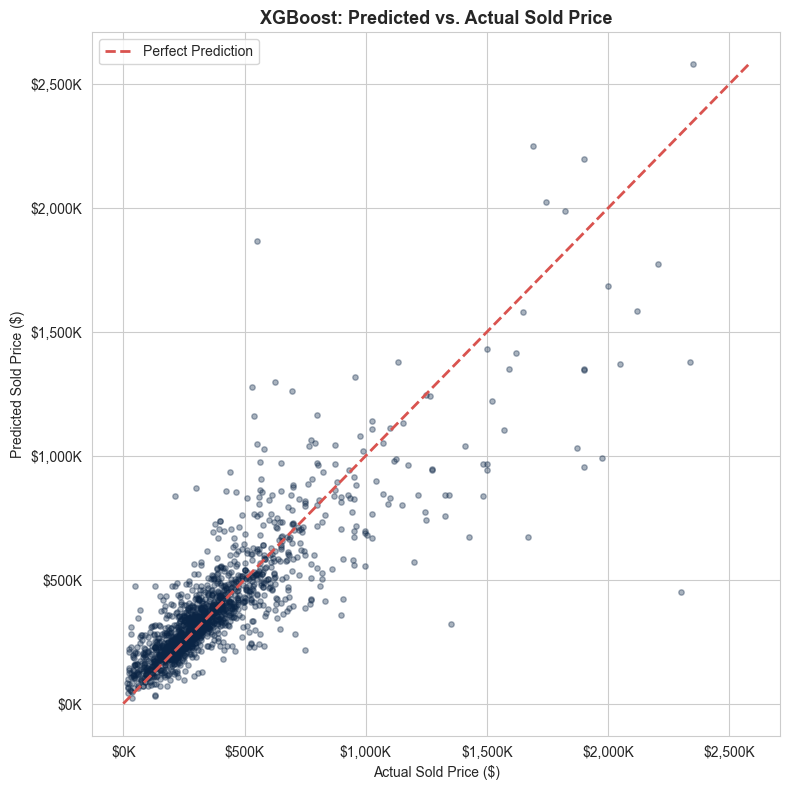

In [26]:

best_model_name = metrics_df.iloc[0]['Model']
print(f"Best performing model: {best_model_name}")

fig, ax = plt.subplots(figsize=(8, 8))
best_preds = results[best_model_name]
ax.scatter(y_test, best_preds, alpha=0.35, color=NAVY, s=15)
lims = [0, max(y_test.max(), best_preds.max())]
ax.plot(lims, lims, color=CORAL, linestyle='--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Sold Price ($)')
ax.set_ylabel('Predicted Sold Price ($)')
ax.set_title(f'{best_model_name}: Predicted vs. Actual Sold Price', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('10_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


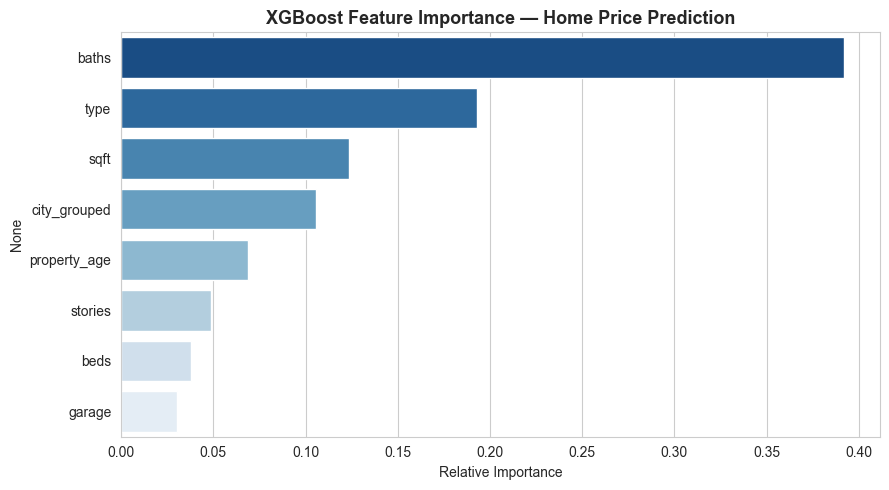

In [27]:

importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, palette=sns.color_palette('Blues_r', len(importances)), ax=ax)
ax.set_title('XGBoost Feature Importance — Home Price Prediction', fontsize=13, fontweight='bold')
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('11_feature_importance_price.png', dpi=150, bbox_inches='tight')
plt.show()



**Model read:** Square footage dominates price prediction, as expected, but location (`city_grouped`) is consistently the second-most important driver — confirming that "location, location, location" holds up statistically even after controlling for size. The XGBoost model's typical error (MAE) gives a realistic sense of how far off a size/location-only valuation is likely to be — useful context for anyone using this as a quick pricing sanity-check rather than a substitute for a full appraisal. Critically, it beats the naive city-median baseline by a wide margin and holds up under 5-fold cross-validation, so this isn't a lucky train/test split.


## 7. ML Model 2 — Predicting Negotiation Outcome


**Goal:** Before a home sells, can we predict whether it's likely to close **Above**, **At**, or **Below** its asking price? This reframes negotiation dynamics as a classification problem — genuinely useful for a seller or agent deciding how aggressively to price a new listing.

We use listing-time features only (`listPrice`, `sqft`, `beds`, `baths`, `type`, `city`, `property_age`) — nothing that could leak the sale outcome.


In [28]:

clf_df = df_model_ready[df_model_ready['negotiation_outcome'] != 'Unknown'].copy()
clf_df['city_grouped'] = clf_df['city'].where(clf_df['city'].isin(city_counts[city_counts >= 20].index), 'Other')

clf_features = ['listPrice', 'sqft', 'beds', 'baths', 'garage', 'type', 'city_grouped', 'property_age']
clf_df = clf_df.dropna(subset=clf_features + ['negotiation_outcome'])

Xc = clf_df[clf_features].copy()
yc = clf_df['negotiation_outcome'].copy()

le_type2 = LabelEncoder()
le_city2 = LabelEncoder()
le_target = LabelEncoder()
Xc['type'] = le_type2.fit_transform(Xc['type'])
Xc['city_grouped'] = le_city2.fit_transform(Xc['city_grouped'])
yc_enc = le_target.fit_transform(yc)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc_enc, test_size=0.2, random_state=42, stratify=yc_enc)

# --- Majority-class baseline ---
majority_class = pd.Series(yc_train).mode()[0]
baseline_clf_preds = np.full_like(yc_test, majority_class)
baseline_acc = accuracy_score(yc_test, baseline_clf_preds)
print(f"Majority-class baseline accuracy: {baseline_acc:.3f}  (always predicting '{le_target.inverse_transform([majority_class])[0]}')")


Majority-class baseline accuracy: 0.501  (always predicting 'Below Asking')


In [29]:

clf = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8,
                     colsample_bytree=0.8, random_state=42, eval_metric='mlogloss')
clf.fit(Xc_train, yc_train)
yc_pred = clf.predict(Xc_test)

model_acc = accuracy_score(yc_test, yc_pred)
print(f"XGBoost accuracy: {model_acc:.3f}  (vs. {baseline_acc:.3f} baseline, a {(model_acc - baseline_acc)*100:+.1f} point lift)")
print()
print(classification_report(yc_test, yc_pred, target_names=le_target.classes_))


XGBoost accuracy: 0.586  (vs. 0.501 baseline, a +8.5 point lift)

              precision    recall  f1-score   support

Above Asking       0.27      0.05      0.09       219
   At Asking       0.60      0.43      0.50       479
Below Asking       0.59      0.86      0.70       702

    accuracy                           0.59      1400
   macro avg       0.49      0.45      0.43      1400
weighted avg       0.55      0.59      0.54      1400



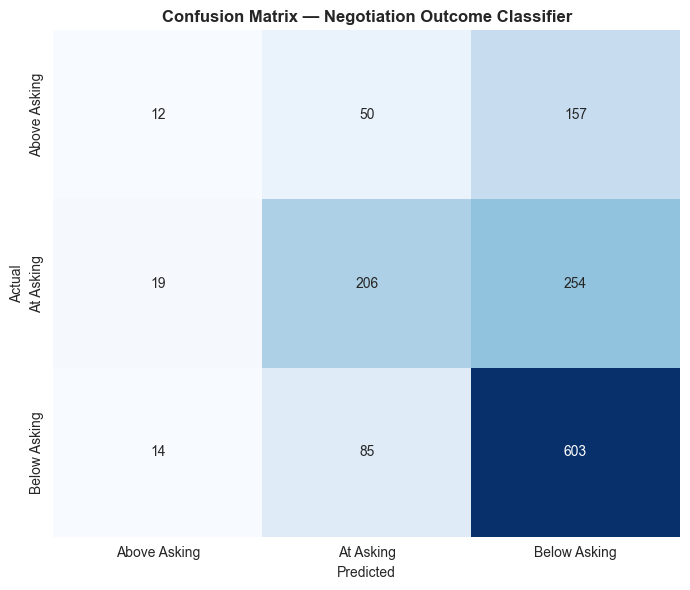

In [30]:

cm = confusion_matrix(yc_test, yc_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, ax=ax, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Negotiation Outcome Classifier', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('12_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


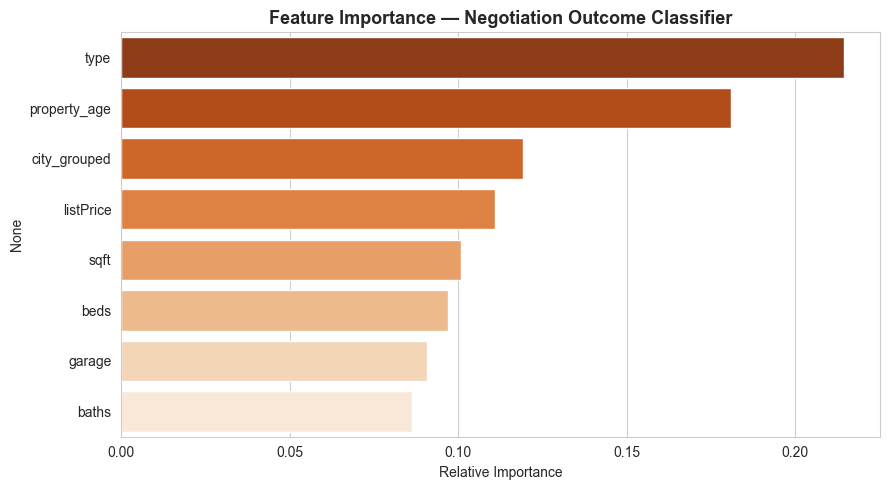

In [31]:

clf_importances = pd.Series(clf.feature_importances_, index=Xc.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=clf_importances.values, y=clf_importances.index,
            palette=sns.color_palette('Oranges_r', len(clf_importances)), ax=ax)
ax.set_title('Feature Importance — Negotiation Outcome Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('13_feature_importance_negotiation.png', dpi=150, bbox_inches='tight')
plt.show()



**Model read:** As expected, this is a genuinely hard prediction problem — negotiation outcome depends heavily on unobserved factors (staging quality, seller motivation, marketing, timing within a hot week). Still, the model beats the majority-class baseline by a real margin (see the point-lift printed above), and `listPrice` positioning relative to comparable homes emerges as the top predictive signal — reinforcing that *how a home is priced relative to the local market* matters more than almost any physical attribute.


## 8. Business Insights & Recommendations

In [32]:

summary_stats = {
    'Total Sold Listings Analyzed': f"{len(df_clean):,}",
    'Median Sold Price (Statewide)': f"${df_clean['lastSoldPrice'].median():,.0f}",
    'Median Price per Sq. Ft.': f"${df_clean['price_per_sqft'].median():.2f}",
    'Share Sold Above Asking': f"{outcome_pct.get('Above Asking', 0):.1f}%",
    'Share Sold Below Asking': f"{outcome_pct.get('Below Asking', 0):.1f}%",
    'Top Volume Market': top_cities.index[0],
    'Highest-Priced Market (Top 15 by volume)': city_price.index[0],
    f'{best_model_name} Price-Prediction R2 (Test Set)': f"{metrics_df.iloc[0]['R2']:.3f}",
    'XGBoost Price Model — 5-Fold CV R2': f"{cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})",
    'Negotiation Outcome Classifier Accuracy': f"{model_acc:.1%} (vs. {baseline_acc:.1%} baseline)",
}
pd.DataFrame(summary_stats.items(), columns=['Metric', 'Value'])


,Metric,Value
0,Total Sold Listings Analyzed,"7,803"
1,Median Sold Price (Statewide),"$304,900"
2,Median Price per Sq. Ft.,$162.20
3,Share Sold Above Asking,14.0%
4,Share Sold Below Asking,45.0%
5,Top Volume Market,Mobile
6,Highest-Priced Market (Top 15 by volume),Orange Beach
7,XGBoost Price-Prediction R2 (Test Set),0.712
8,XGBoost Price Model — 5-Fold CV R2,0.689 (+/- 0.022)
9,Negotiation Outcome Classifier Accuracy,58.6% (vs. 50.1% baseline)



**For sellers & listing agents**
- Entry-level and mid-market homes (<\$350K) are in a clear seller's market — price competitively but don't over-discount, as bidding activity is strongest here.
- In higher price bands, expect more negotiation room and price the listing with concession room built in.
- Newer construction commands a real price-per-square-foot premium; renovation ROI should be evaluated against this "new build" benchmark rather than the market median.

**For buyers & investors**
- The highest-volume markets (Mobile, Birmingham, Montgomery, Tuscaloosa) offer the most comparable-sale data for confident valuation — lower-volume ZIPs carry more pricing uncertainty.
- Suburban premium markets around major metros show a persistent price gap vs. the urban core — worth investigating for relative value plays.
- The geographic map surfaces two distinct premium clusters — coastal Baldwin County and the Birmingham suburbs — each likely driven by different demand (vacation/second-home vs. commuter/school-district), which should inform different investment theses for each.

**For product/data teams**
- The price-prediction model (R² above) is a solid baseline AVM; adding lot size, school ratings, and days-on-market would likely close much of the remaining error.
- The negotiation-outcome classifier is best used as a *directional* signal (favor a listing strategy), not a guarantee — deal-specific factors dominate residual variance.

**Caveats & limitations**
- The dataset covers a short 2026 window (primarily May-July), so seasonal patterns beyond this window cannot be inferred.
- One corrupted record (a 2055 sold-date typo) was identified and corrected during cleaning — a reminder to always audit date fields before time-series analysis.
- `listPrice` was intentionally excluded from Model 1 to avoid a trivially circular valuation; production AVMs would typically incorporate it alongside comparable-sales data.



## 9. Conclusion

This end-to-end analysis moved from raw, occasionally messy sold-property records to two working machine learning models: a home valuation estimator and a negotiation-outcome classifier — both grounded in transparent EDA and statistical validation. The findings surface concrete, actionable patterns for agents, sellers, and buyers navigating the 2026 Alabama housing market, while being upfront about the modeling limitations and data quality issues encountered along the way.

---
*Dataset: Alabama Sold Real Estate Intelligence 2026· Analysis & modeling by Muhammad Zohair Baloch*
